<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/02_02_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 올바른 결과를 도출하기 위해서, 데이터를 사용하기 전에 데이터 전처리 과정을 거친다.
# 전처리 과정을 거친 데이터로 훈련했을 때의 차이를 알고, 표준 점수로 특성의 스케일을 변환해 보자.

# 만약 길이와 무게가 각각 25cm, 150g인데 빙어로 결론이 나온다면?
# 원인을 분석하고 개선해 보자.

# 전처리 데이터의 앞쪽 35개는 도미(1), 뒤쪽 14개는 빙어(0) → 총 49개
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]

fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
# 전에는 파이썬 리스트를 'for문'과 'zip'을 활용하여 배열로 만들었지만, 넘파이에서는 이 기능이 내장되어 있는 매서드가 존재한다.
import numpy as np # 넘파이 배열용 파이썬 라이브러리
np.column_stack(([1, 2, 3], [4, 5, 6])) # .column(열)_stack(쌓다)
#                  길이용     무게용 → 변환

array([[1, 4],
       [2, 5],
       [3, 6]])

In [3]:
fish_data = np.column_stack((fish_length, fish_weight)) # 'fish_data' 변수에 2차원 배열을 넣는다. (앞쪽 : 길이, 뒤쪽 : 무게)
print(fish_data[:5]) # 앞쪽 5개의 데이터를 미리 확인해본다. (0 ~ 4번 인덱스를 확인한다.)

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


In [4]:
# '정답(target)이 1이면 도미, 0이면 빙어' 만들기 → 정답 파일을 생성한다.
print(np.ones(5)) # 1로 채우기

[1. 1. 1. 1. 1.]


In [5]:
print(np.zeros(10)) # 0으로 채우기

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
# .concatenate() : 첫 번째 차원을 따라 배열을 연결한다.
# 1차원 배열 (1이 35개(도미), 0이 14개(빙어))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, stratify = fish_target, random_state = 42
)

print(train_input.shape, test_input.shape)

# train_input : 훈련용 입력값
# test_input : 테스트용 입력값
# train_target : 훈련용 정답
# test_target : 테스트용 정답
# stratify : 타깃값을 넣어준다. (target의 class 비율을 유지한 채 데이터셋을 split 한다.)
# random_state : 시드 값을 42로 지정한 후 무작위로 적용한다. (수업용)

# 결과 : 무작위로 처리한다. → 훈련용(36(객체), 2(특성)) 테스트용(13(객체), 2(특성))

(36, 2) (13, 2)


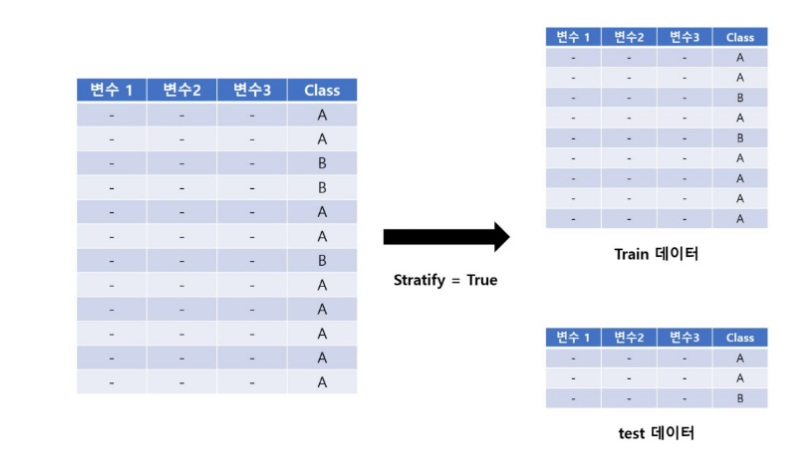

In [9]:
print(train_target.shape, test_target.shape) # 결과가 튜플로 추출된다.

(36,) (13,)


In [10]:
print(train_target) # 훈련용 정답 데이터

[1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1.
 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1.]


In [11]:
print(test_target) # 테스트용 검증 데이터 → 결론적으로 적절하게 분배되었다.

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# ----------------------------- 전처리 데이터 끝 -----------------------------

In [12]:
from sklearn.neighbors import KNeighborsClassifier # K - 최근접 이웃 알고리즘

kn = KNeighborsClassifier() # 객체를 생성한다.
kn.fit(train_input, train_target) # 훈련을 시작한다.

KNeighborsClassifier()

In [13]:
kn.score(test_input, test_target) # 평가를 시작한다.

1.0

In [15]:
print(kn.predict([[25,150]])) # 마찬가지로 '0(빙어)'이 출력된다.

[0.]


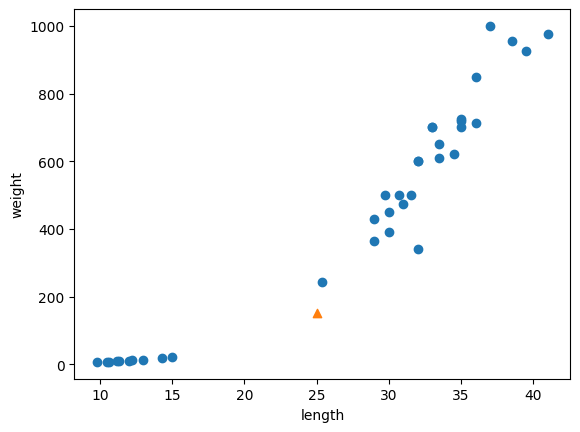

In [16]:
# 그래프로 확인해보자.
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker = '^') # 마커 종류 변경 : https://pyvisuall.tistory.com/39
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

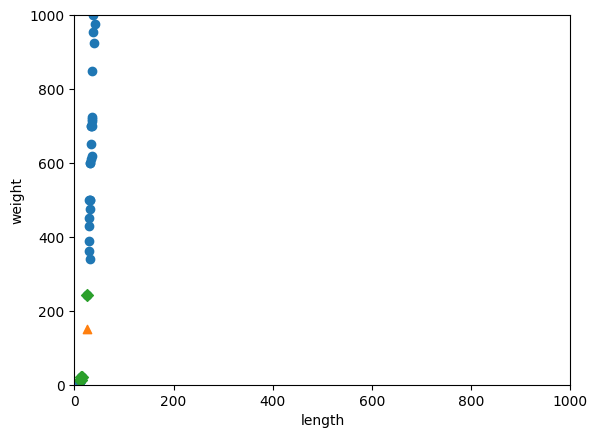

In [19]:
# 결론 : x축과 y축의 비율이 다르기 때문에 그래프로 정확하게 판단할 수 없다.
# 'K - 최근접 이웃 알고리즘'은 주변에 존재하는 5개의 데이터로 판단하기 때문에 좀 더 알아볼 필요가 있다.

distances, indexes= kn.kneighbors([[25,150]])
# 내가 확인하고 싶은 값의 거리와 인덱스를 알아보자.
plt.scatter(train_input[:,0], train_input[:,1]) # 입력 데이터 값
plt.scatter(25, 150, marker = '^') # 확인하고 싶은 값
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D') # 이웃한 값
plt.xlim((0, 1000)) # x축의 범위 : 0 ~ 1,000
plt.ylim((0, 1000)) # y축의 범위 : 0 ~ 1,000
plt.xlabel('length')
plt.ylabel('weight')
plt.show()
# 결론 : 녹색으로 '25, 150'에 대한 이웃한 값이 무엇인지 파악할 수 있다.

In [20]:
print(train_input[indexes]) # 'K - 최근접 이웃 알고리즘'에 근접한 5개의 값 (도미 1, 빙어 4)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]


In [21]:
print(train_target[indexes]) # 도미 1, 빙어 4

[[1. 0. 0. 0. 0.]]


In [22]:
print(distances) # 이웃 간의 거리 출력

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


In [23]:
# 두 특성(길이, 무게)의 값이 놓인 범위가 매우 다르다. == 두 특성의 스케일이 다르다.
# 특성 간의 스케일이 다른 일은 흔하게 발생한다. → 스케일을 맞춰야 한다.
# 특성 값을 일정한 기준으로 맞춰줘야 한다. (데이터 전처리)

# 평균을 구해보자 (가장 널리 사용하는 전처리 방법 : 표준 점수(Z 점수))
# 표준 점수 : 각 특성 값이 평균에서 표준편차의 몇 배만큼 떨어져 있는지를 나타낸다.
# 분산 : 데이터에서 평균을 뺀 값을 모두 제곱한 다음 평균을 내어 구한다.
# 표준 편차 : 분산의 제곱근으로, 데이터가 분산된 정도를 나타낸다.

mean = np.mean(train_input, axis = 0) # 평균을 구한다 (axis : 중심선)
std = np.std(train_input, axis = 0) # 표준편차를 구한다.
# train_input → 36개의 요소와 2개의 특성을 가진다. == (36, 2) 크기의 배열이다.
# 행을 따라 각 열의 통계 값을 계산한다.
print(mean, std)
# 결과 : [ 27.29722222 454.09722222] [  9.98244253 323.29893931]
#          길이의 평균  무게의 평균     길이의 편차 무게의 편차

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


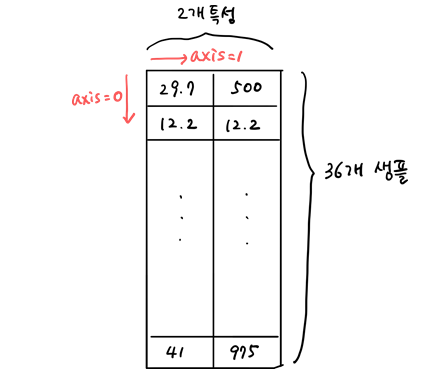

In [24]:
# 원본 데이터에서 평균을 빼고, 표준편차로 나누어 표준 점수를 반환한다.
train_scaled = (train_input - mean) / std # 표준 점수 공식 (암기)

# 넘파이는 'train_input'의 모든 행에서 mean에 있는 두 평균값을 빼준다.
# std에 있는 두 표준편차를 다시 모든 행에 적용한다. (브로드캐스팅)

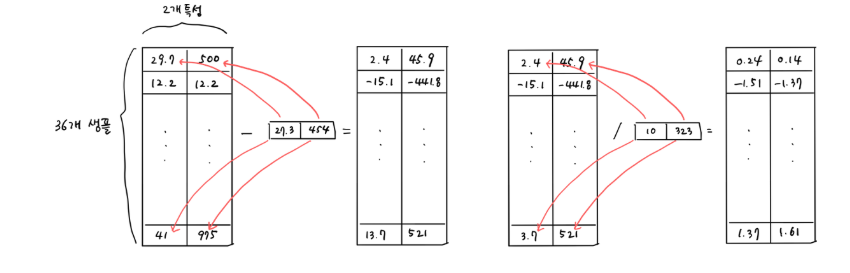

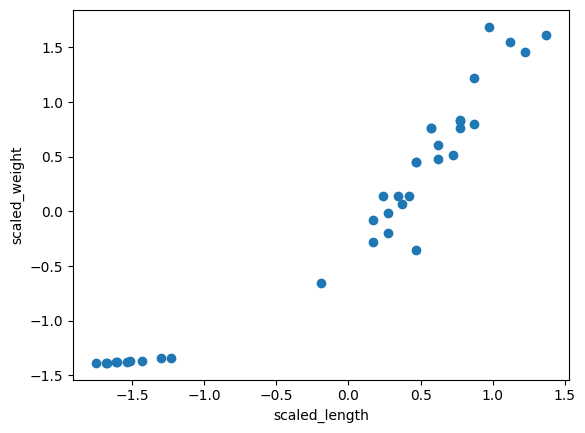

In [25]:
# 위 공식대로 적용하면, 길이 41cm와 무게 975g의 스케일이 1.37, 1.81로 표준화된다.
# 전처리 데이터를 활용하여 모델을 훈련시킨다.
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.xlabel("scaled_length")
plt.ylabel("scaled_weight")
plt.show()
# 결과 : 차트 범위가 x축은 - 2.0 ~ 1.5, y축은 - 1.5 ~ 1.5 사이로 비슷해진다. (스케일 조정 성공)
# 전에 만들었던 표준 점수 이전 차트와 비교하면 비슷한 차트가 보인다.

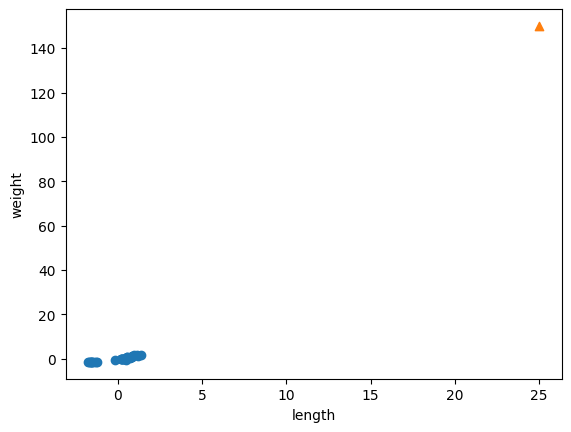

In [26]:
# 전처리 데이터를 활용하여 모델을 훈련시키기
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker = '^') # 알고 싶은 추가 데이터
plt.xlabel("length")
plt.ylabel("weight")
plt.show() # 오른쪽 맨 꼭대기에 수상한 샘플이 추출된다.
# 전처리된 데이터는 표준 점수를 위해서 값이 축소되어 있는데, 알고자 하는 값은 표준 점수화가 안 된다.
# 훈련 세트를 평균으로 빼고 표준편차로 나눴기 때문에 값의 범위가 달라진다.

표준 점수로 변환된 25, 150 : [-0.23012627 -0.94060693]


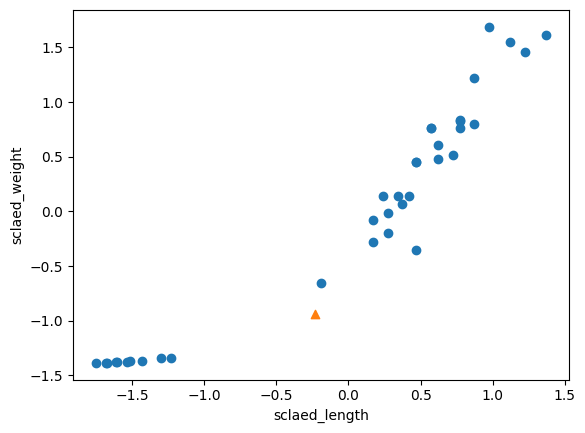

In [27]:
# 동일한 기준으로 샘플을 변환하고 출력한다.
new = ([25, 150] - mean) / std
print(f"표준 점수로 변환된 25, 150 : {new}")

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker = '^') # 배열로 생성하고 표준편차 적용 후 추가한 데이터
plt.xlabel("sclaed_length")
plt.ylabel("sclaed_weight")
plt.show()
# 결과 : x축과 y축의 범위가 비슷하다. (- 1.5 ~ 1.5 사이의 값)

In [28]:
# 훈련을 시작한다.
kn.fit(train_scaled, train_target) # 스케일 조정된 입력값으로 타겟을 훈련시킨다.

KNeighborsClassifier()

In [30]:
# 테스트 진행 전 표준 점수로 변환해야 한다.
test_scaled = (test_input - mean) / std # 표준 점수화

In [31]:
kn.score = (test_scaled, test_target) # 평가를 진행한다.
new = ([25, 150] - mean) / std
print(kn.predict([new]))
# 결과 : '25, 150'의 결과를 보면 '[1.](도미)'로 예측 성공한다.

[1.]


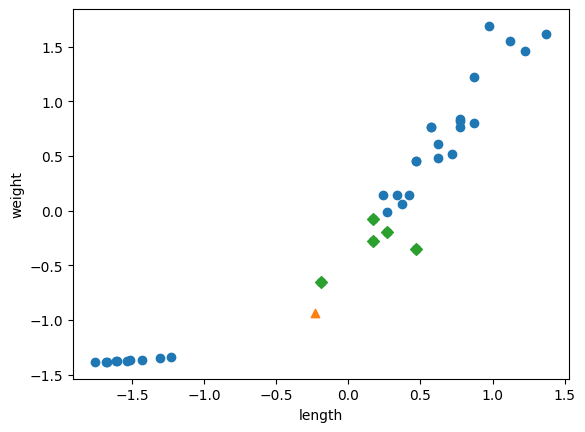

In [32]:
# 'kneighbors()'로 최근접 이웃을 구한 다음 산점도로 그려보자.
distances, indexes = kn.kneighbors([new])
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0],new[1], marker = '^')
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker = 'D')
plt.xlabel("length")
plt.ylabel("weight")
plt.show()